# Notebook 1 — Exploratory Data Analysis

**Goal:** Understand the Olist dataset before building any model.

**Prerequisite:** Run `python data\load_kaggle.py` before opening this notebook.

---

### What we will explore
1. Table row counts — is the data loaded?
2. Order status distribution
3. Monthly revenue trend
4. Order value distribution
5. Top product categories
6. Review score distribution
7. Revenue by state
8. Churn baseline check

In [5]:
# import libraries
import sys
sys.path.append('../..')
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')


from sqlalchemy import text
from src.db import engine


plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (13, 5)

print('All imports OK.')

All imports OK.


## 1. Table row counts
First check that all tables have data. If any table shows 0, run `python data\load_kaggle.py`.

In [6]:
tables = [
    'dim_customers','dim_sellers','dim_products','dim_date',
    'fact_orders','fact_order_items','fact_payments','fact_reviews'
]

print(f'  {"Table":<30} {"Rows":>10}')
print('  ' + '-'*42)

with engine.connect() as conn:
    for t in tables:
        n = conn.execute(text(f'SELECT COUNT(*) FROM {t}')).scalar()
        status = 'Yes' if n > 0 else 'EMPTY — run load_kaggle.py'
        print(f'  {t:<30} {n:>10,}  {status}')



  Table                                Rows
  ------------------------------------------
  dim_customers                      99,441  Yes
  dim_sellers                         3,095  Yes
  dim_products                       32,951  Yes
  dim_date                              634  Yes
  fact_orders                        99,441  Yes
  fact_order_items                  112,650  Yes
  fact_payments                     103,886  Yes
  fact_reviews                       98,410  Yes


## 2. Order status distribution

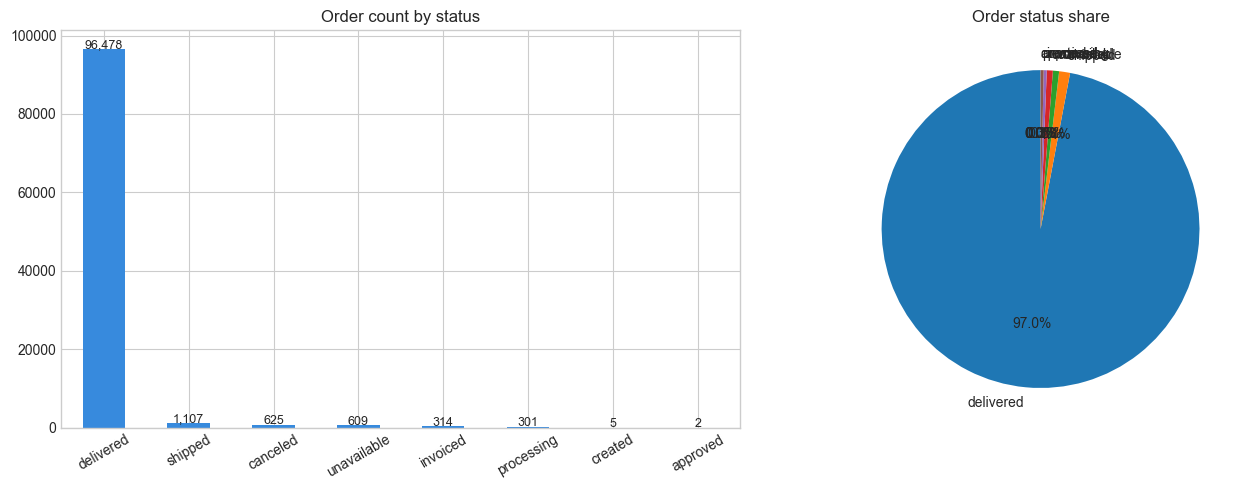

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


In [7]:
orders = pd.read_sql('SELECT order_id, order_status, purchase_date FROM fact_orders', engine)
status = orders['order_status'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

status.plot(kind='bar', ax=axes[0], color='#378ADD', edgecolor='none')
axes[0].set_title('Order count by status')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=30)
for i, v in enumerate(status):
    axes[0].text(i, v + 200, f'{v:,}', ha='center', fontsize=9)

axes[1].pie(status.values, labels=status.index,
            autopct='%1.1f%%', startangle=90,
            colors=plt.cm.tab10.colors)
axes[1].set_title('Order status share')

plt.tight_layout()
plt.savefig('../../docs/screenshots/01_order_status.png', dpi=120, bbox_inches='tight')
plt.show()
print(status)

## 3. Monthly revenue trend

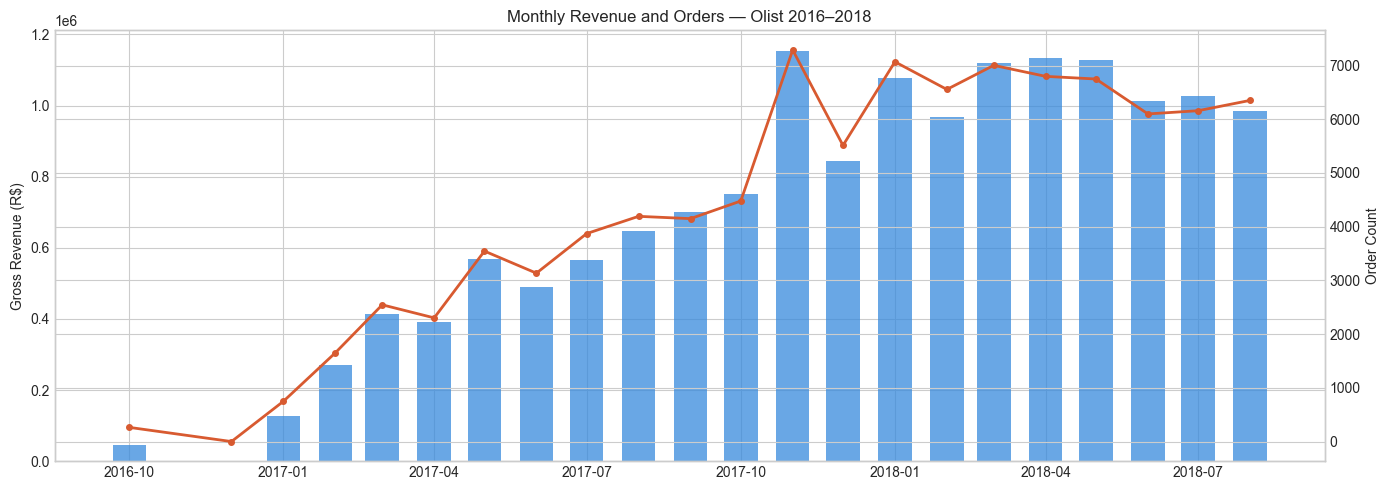

Total revenue  : R$ 15,422,461.77
Total orders   : 96,477
Peak month rev : R$ 1,153,528.05


In [8]:
monthly = pd.read_sql("""
    SELECT
        DATE_TRUNC('month', o.purchase_date)::DATE   AS month,
        COUNT(DISTINCT o.order_id)                    AS orders,
        ROUND(SUM(p.payment_value)::NUMERIC, 2)       AS revenue
    FROM fact_orders   o
    JOIN fact_payments  p ON p.order_id = o.order_id
    WHERE o.order_status = 'delivered'
    GROUP BY 1
    ORDER BY 1
""", engine)

monthly['month'] = pd.to_datetime(monthly['month'])

fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()

ax1.bar(monthly['month'], monthly['revenue'], width=20,
        color='#378ADD', alpha=0.75, label='Gross revenue (R$)')
ax2.plot(monthly['month'], monthly['orders'], color='#D85A30',
         linewidth=2, marker='o', markersize=4, label='Orders')

ax1.set_ylabel('Gross Revenue (R$)')
ax2.set_ylabel('Order Count')
ax1.set_title('Monthly Revenue and Orders — Olist 2016–2018')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()


plt.tight_layout()
plt.savefig('../../docs/screenshots/02_monthly_revenue.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'Total revenue  : R$ {monthly["revenue"].sum():,.2f}')
print(f'Total orders   : {monthly["orders"].sum():,}')
print(f'Peak month rev : R$ {monthly["revenue"].max():,.2f}')

## 4. Order value distribution

Order value statistics:
count    99440.00
mean       160.99
std        221.95
min          0.00
25%         62.01
50%        105.29
75%        176.97
max      13664.08
Name: payment_value, dtype: float64


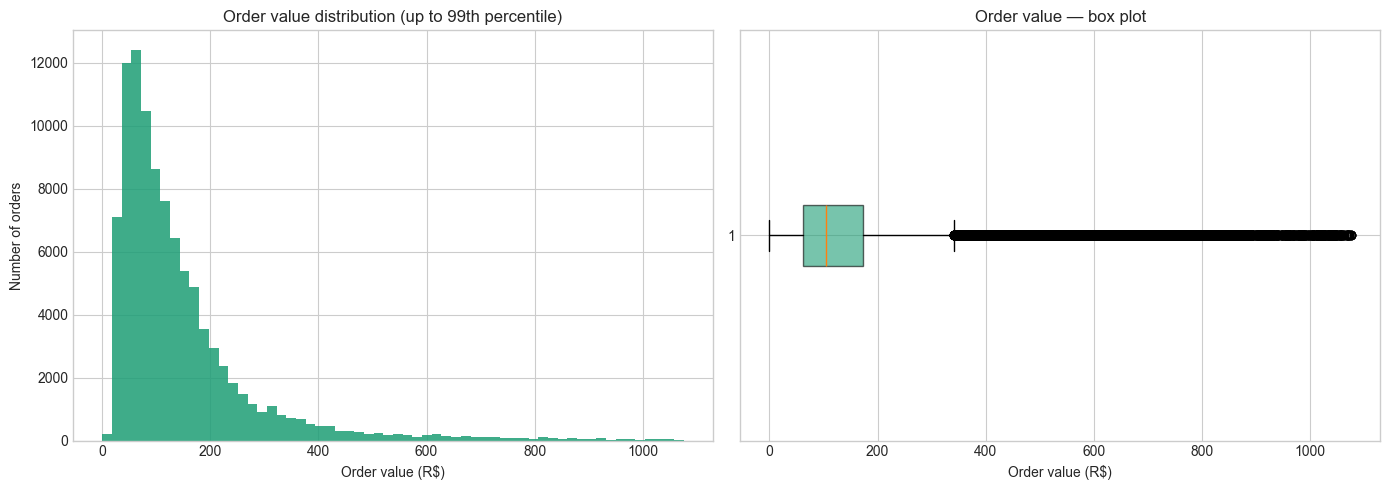

In [9]:
payments = pd.read_sql('SELECT order_id, payment_value FROM fact_payments', engine)
order_vals = payments.groupby('order_id')['payment_value'].sum()

print('Order value statistics:')
print(order_vals.describe().round(2))

p99 = order_vals.quantile(0.99)
clean = order_vals[order_vals <= p99]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(clean, bins=60, color='#1D9E75', edgecolor='none', alpha=0.85)
axes[0].set_title('Order value distribution (up to 99th percentile)')
axes[0].set_xlabel('Order value (R$)')
axes[0].set_ylabel('Number of orders')

axes[1].boxplot(clean, vert=False, patch_artist=True,
                boxprops=dict(facecolor='#1D9E75', alpha=0.6))
axes[1].set_title('Order value — box plot')
axes[1].set_xlabel('Order value (R$)')

plt.tight_layout()
plt.savefig('../../docs/screenshots/03_order_value_dist.png', dpi=120, bbox_inches='tight')
plt.show()

## 5. Top 15 product categories

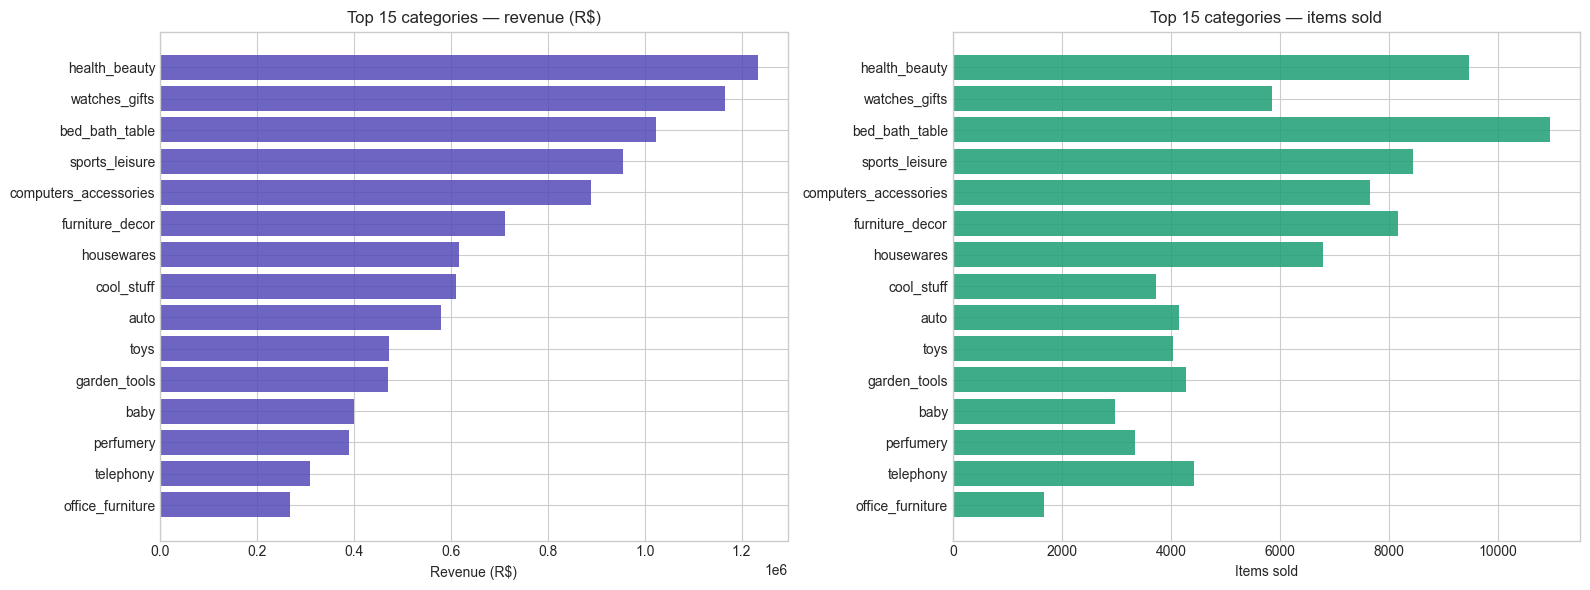

In [10]:
cats = pd.read_sql("""
    SELECT
        COALESCE(p.category_name_english, 'unknown')  AS category,
        COUNT(i.item_id)                               AS items_sold,
        ROUND(SUM(i.price)::NUMERIC, 2)                AS revenue
    FROM fact_order_items  i
    JOIN dim_products       p ON p.product_id = i.product_id
    JOIN fact_orders        o ON o.order_id   = i.order_id
    WHERE o.order_status = 'delivered'
    GROUP BY 1
    ORDER BY revenue DESC
    LIMIT 15
""", engine)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(cats['category'][::-1], cats['revenue'][::-1],
             color='#534AB7', alpha=0.85)
axes[0].set_title('Top 15 categories — revenue (R$)')
axes[0].set_xlabel('Revenue (R$)')

axes[1].barh(cats['category'][::-1], cats['items_sold'][::-1],
             color='#1D9E75', alpha=0.85)
axes[1].set_title('Top 15 categories — items sold')
axes[1].set_xlabel('Items sold')

plt.tight_layout()
plt.savefig('../../docs/screenshots/04_top_categories.png', dpi=120, bbox_inches='tight')
plt.show()

## 6. Review score distribution

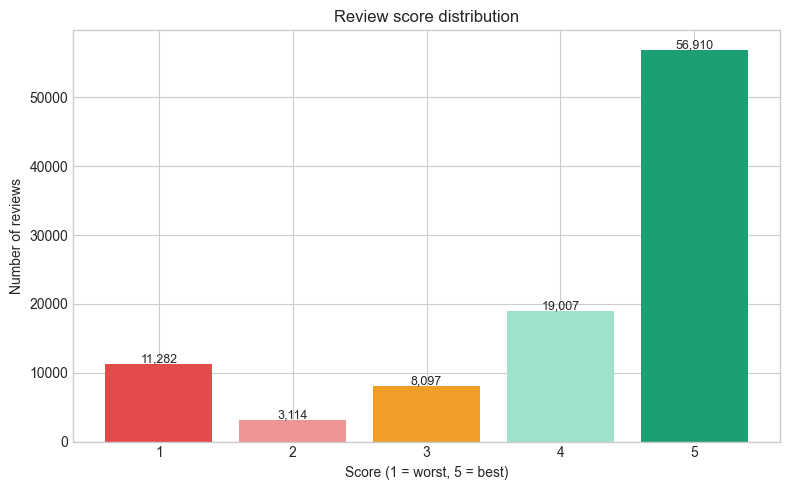

Average review score : 4.09
5-star reviews       : 57.8%
1-star reviews       : 11.5%


In [11]:
reviews = pd.read_sql('SELECT review_score FROM fact_reviews', engine)
scores  = reviews['review_score'].value_counts().sort_index()

colors = ['#E24B4A','#F09595','#EF9F27','#9FE1CB','#1D9E75']
plt.figure(figsize=(8, 5))
bars = plt.bar(scores.index, scores.values, color=colors, edgecolor='none')
plt.title('Review score distribution')
plt.xlabel('Score (1 = worst, 5 = best)')
plt.ylabel('Number of reviews')
for bar, cnt in zip(bars, scores.values):
    plt.text(bar.get_x() + bar.get_width()/2, cnt + 300,
             f'{cnt:,}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('../../docs/screenshots/05_review_scores.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'Average review score : {reviews["review_score"].mean():.2f}')
print(f'5-star reviews       : {(reviews["review_score"]==5).mean()*100:.1f}%')
print(f'1-star reviews       : {(reviews["review_score"]==1).mean()*100:.1f}%')

## 7. Revenue by state

In [12]:
geo = pd.read_sql("""
    SELECT
        c.state,
        COUNT(DISTINCT c.customer_unique_id)       AS customers,
        COUNT(DISTINCT o.order_id)                 AS orders,
        ROUND(SUM(p.payment_value)::NUMERIC, 2)    AS revenue
    FROM fact_orders    o
    JOIN dim_customers  c ON c.customer_id = o.customer_id
    JOIN fact_payments  p ON p.order_id    = o.order_id
    WHERE o.order_status = 'delivered'
    GROUP BY c.state
    ORDER BY revenue DESC
""", engine)

fig = px.bar(
    geo.head(12), x='state', y='revenue',
    color='customers', color_continuous_scale='Blues',
    title='Revenue and customers by state (top 12)',
    labels={'revenue':'Revenue (R$)','customers':'Customers','state':'State'}
)
fig.show()

print(geo.head(10).to_string(index=False))

state  customers  orders    revenue
   SP      39155   40500 5770266.19
   RJ      11917   12350 2055690.45
   MG      11001   11354 1819277.61
   RS       5168    5345  861802.40
   PR       4769    4923  781919.55
   SC       3449    3546  595208.40
   BA       3158    3256  591270.60
   DF       2019    2080  346146.17
   GO       1895    1957  334294.22
   ES       1928    1995  317682.65


## 8. Churn baseline check

In [13]:
churn_check = pd.read_sql("""
    SELECT
        SUM(CASE WHEN recency_days > 180 THEN 1 ELSE 0 END)  AS churned,
        COUNT(*)                                               AS total
    FROM (
        SELECT
            c.customer_unique_id,
            EXTRACT(DAY FROM NOW() - MAX(o.purchase_date))::INT  AS recency_days
        FROM fact_orders    o
        JOIN dim_customers  c ON c.customer_id = o.customer_id
        WHERE o.order_status = 'delivered'
        GROUP BY c.customer_unique_id
    ) t
""", engine).iloc[0]

churn_rate = churn_check['churned'] / churn_check['total'] * 100

print('── Churn Baseline ──────────────────────────────')
print(f'  Total unique customers : {churn_check["total"]:>10,}')
print(f'  Churned (> 180 days)   : {churn_check["churned"]:>10,}')
print(f'  Churn rate             : {churn_rate:>9.1f} %')
print('────────────────────────────────────────────────')
print()
print('EDA complete. All screenshots saved to docs\\screenshots\\')

── Churn Baseline ──────────────────────────────
  Total unique customers :     93,358
  Churned (> 180 days)   :     93,358
  Churn rate             :     100.0 %
────────────────────────────────────────────────

EDA complete. All screenshots saved to docs\screenshots\
